# 작업형 제1유형

다음 데이터에서 IotSizeSqFt이 큰 top 10을 구하고, top 10 값 중 가장 작은 값으로 해당 값을 대치하시오. 또한, 건축 연도(yearBuilt) 가 2000 년도 이상인 IotSizeSqFt 의 평균값을 구하시오. (소수점 첫째 자리에서 반올림, 대치된 IotSizeSqFt 기준) 

In [109]:
import pandas as pd 
df = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_1.csv")
display(df.head(3))

df = df.sort_values('lotSizeSqFt',ascending=False).reset_index()
min_val = df['lotSizeSqFt'][9]

df['lotSizeSqFt'][0:10] = min_val 

df2 = df[(df['yearBuilt'] >= 2000)]
print('건축연도가 2000 년도 이상인 lotSizeSqft 의 평균 : ',round(df2['lotSizeSqFt'].mean(),2))


,city,homeType,latitude,longitude,garageSpaces,hasSpa,yearBuilt,numOfPatioAndPorchFeatures,lotSizeSqFt,avgSchoolRating,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,priceRange
0,austin,Single Family,30.197647,-97.816811,2,False,1981,0,9757.0,4.0,13,NaN,3,350000-450000
1,austin,Single Family,30.329187,-97.752731,2,False,1951,0,10846.0,7.0,16,NaN,4,650000+
2,austin,Single Family,30.313305,-97.699669,0,False,1954,0,9016.0,5.0,15,NaN,3,350000-450000


건축연도가 2000 년도 이상인 lotSizeSqft 의 평균 :  12954.92


/var/folders/gw/jvr6w8xj12gc01xmg3zw29pw0000gn/T/ipykernel_4118/227987410.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['lotSizeSqFt'][0:10] = min_val
/var/folders/gw/jvr6w8xj12gc01xmg3zw29pw0000gn/T/ipykernel_4118/227987410.py:8: S

칼럼별 결측치 존재 여부를 확인하고, 결측치가 존재하는 경우 해당 칼럼의 중앙값으로 결측치를 대치하시오. 결측치 대치 전과 후 표준편차 차이의 절댓값을 구하시오. (소수점 둘째 자리까지 반올림)

In [35]:
print(df.isnull().sum())

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

encoded = imputer.fit_transform(df[['numOfBathrooms']])
df3 = df.copy()
df3['numOfBathrooms'] = encoded
print(f"결측치 대치 전 numOfBathrooms 의 표준편차 : {round(df['numOfBathrooms'].std(),2)}")
print(f"결측치 대치 후 numOfBathrooms 의 표준편차 : {round(df3['numOfBathrooms'].std(),2)}")

print(f"표준편차 절대값 차이 : {round(abs(df['numOfBathrooms'].std()-df3['numOfBathrooms'].std()),2)}")

index                          0
city                           0
homeType                       0
latitude                       0
longitude                      0
garageSpaces                   0
hasSpa                         0
yearBuilt                      0
numOfPatioAndPorchFeatures     0
lotSizeSqFt                    0
avgSchoolRating                0
MedianStudentsPerTeacher       0
numOfBathrooms                11
numOfBedrooms                  0
priceRange                     0
dtype: int64
결측치 대치 전 numOfBathrooms 의 표준편차 : 0.99
결측치 대치 후 numOfBathrooms 의 표준편차 : 0.98
표준편차 절대값 차이 : 0.01


평균으로부터 1.5 X 표준편차만큼 벗어나는 경우를 이상치로 판단할 때, MedianStudentsPerTeacher 의 이상치를 구하고, 이상치의 개수를 구하시오 

In [110]:
display(df.head(3))
print(f"MedianStudentsPerTeacher 의 평균 : {df['MedianStudentsPerTeacher'].mean()}")
print(f"MedianStudentsPerTeacher 의 표준편차 : {df['MedianStudentsPerTeacher'].std()}")

mean, std = df['MedianStudentsPerTeacher'].mean(), df['MedianStudentsPerTeacher'].std()
out_min = mean - std*1.5
out_max = mean + std*1.5

df4 = df[(df['MedianStudentsPerTeacher']<out_min)|(df['MedianStudentsPerTeacher']>out_max)]
print("이상치의 갯수 : ",len(df4))

,index,city,homeType,latitude,longitude,garageSpaces,hasSpa,yearBuilt,numOfPatioAndPorchFeatures,lotSizeSqFt,avgSchoolRating,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,priceRange
0,412,austin,Single Family,30.169123,-97.989502,0,False,2010,0,71438.4,8.000000,15,3.0,4,350000-450000
1,6,austin,Single Family,30.143131,-97.963493,0,False,1985,0,71438.4,7.000000,16,NaN,3,0-250000
2,175,austin,Single Family,30.233570,-98.008072,7,True,2017,3,71438.4,6.666667,16,4.0,4,650000+


MedianStudentsPerTeacher 의 평균 : 15.088
MedianStudentsPerTeacher 의 표준편차 : 1.6738756582969003
이상치의 갯수 :  65


# 작업형 제2유형

훈련 데이터로 학습한 모델을 테스트 데이터에 적용하여 예측한 결과를 제출하시오. (target : Outcome 이 1일 확률)  
평가지표 : f1_score   


In [78]:
import pandas as pd 
X = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_trainX.csv")
y = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_trainy.csv")
test_X = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_testX.csv")

In [79]:
display(X.head(3))
display(y.head(3))
display(test_X.head(3))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,151,90,46,0,42.1,0.371,21
1,1,83,68,0,0,18.2,0.624,27
2,2,122,70,27,0,36.8,0.340,27


,Outcome
0,1
1,0
2,0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,199,76,43,0,42.9,1.394,22
1,2,107,74,30,100,33.6,0.404,23
2,4,76,62,0,0,34.0,0.391,25


In [80]:
print(X.isnull().sum())
print(y.isnull().sum())
print(test_X.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
Outcome    0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


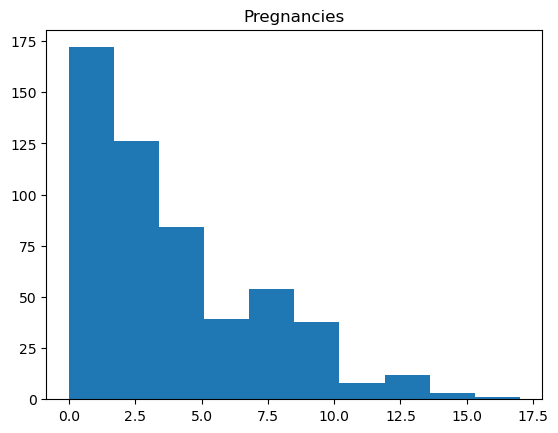

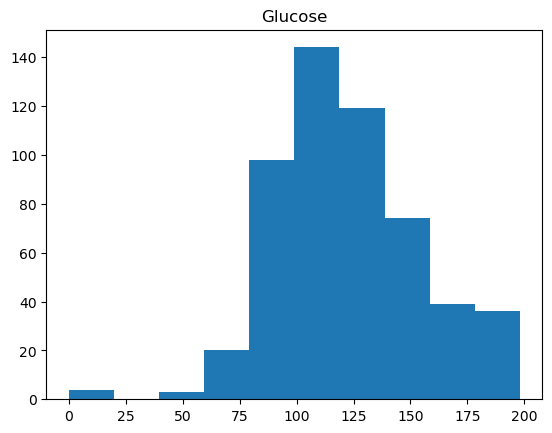

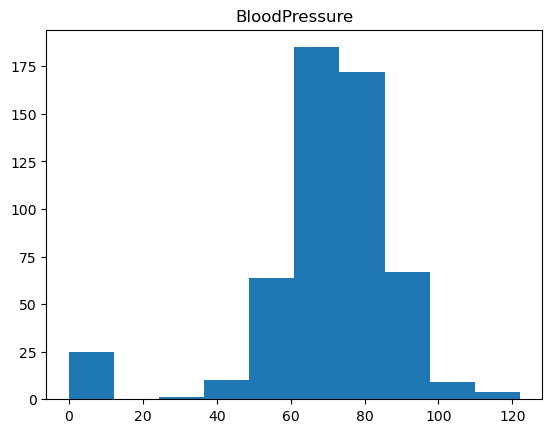

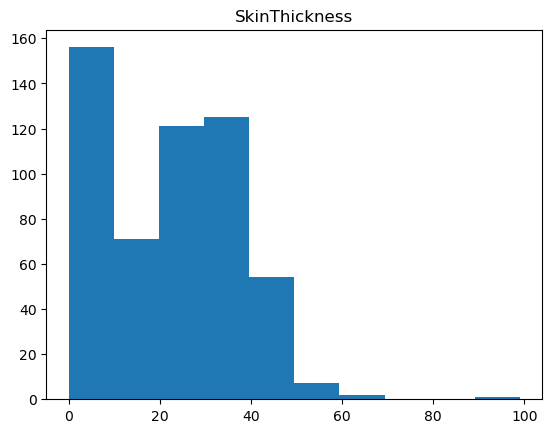

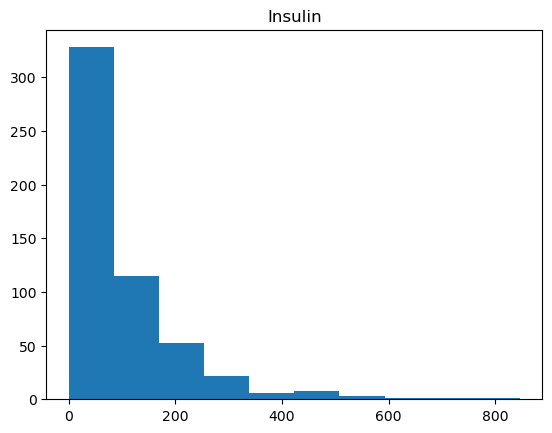

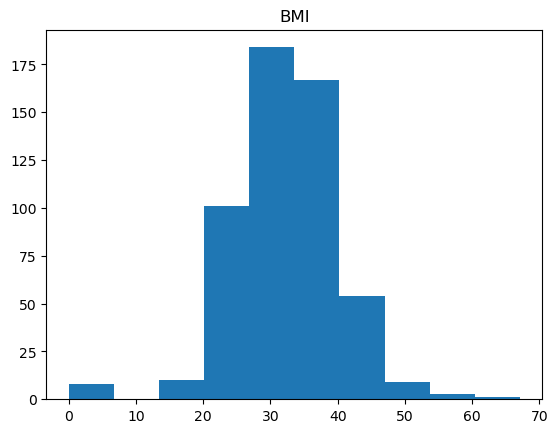

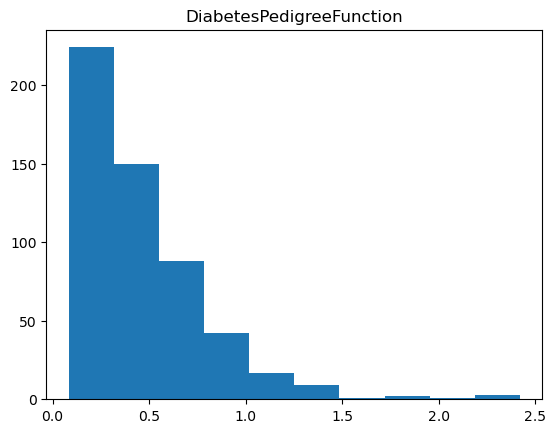

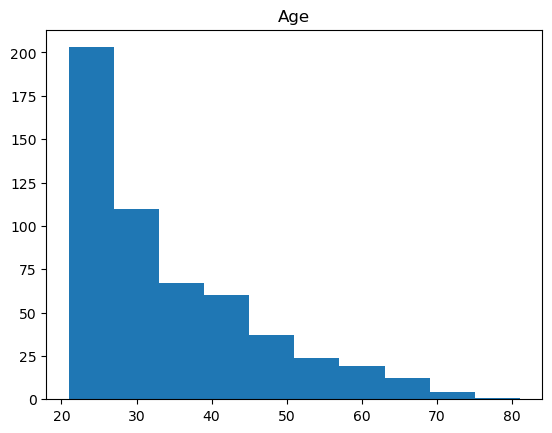

In [92]:
import matplotlib.pyplot as plt 
indices = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']
for i in indices : 
    plt.hist(X[i])
    plt.title(i)
    plt.show()
#for i in len(X):
#    plt.hist(X[i])

In [107]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import f1_score 

X = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_trainX.csv")
y = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_trainy.csv")

import numpy as np 
X['Pregnancies'] = np.log1p(X['Pregnancies'])
X['SkinThickness'] = np.log1p(X['SkinThickness'])
X['Insulin'] = np.log1p(X['Insulin'])
X['DiabetesPedigreeFunction'] = np.log1p(X['DiabetesPedigreeFunction'])
X['Age'] = np.log1p(X['Age'])

train_X, valid_X, train_y, valid_y = train_test_split(X,y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(max_depth=5)
rf.fit(train_X,train_y)
prediction = rf.predict(valid_X)
f1 = f1_score(valid_y,prediction)
print(f"f1 score : {round(f1,2)}")

f1 score : 0.55


/Users/isumi/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [113]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import f1_score 

X = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_trainX.csv")
y = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_trainy.csv")
test_X = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_2_testX.csv")

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.3, random_state=1)

rf = RandomForestClassifier(random_state=1)
rf.fit(train_X,train_y)
prediction = rf.predict(valid_X)
f1 = f1_score(valid_y,prediction,average='macro')
print(f"f1 score : {round(f1,2)}")

pred_real = rf.predict(test_X)

f1 score : 0.76


/Users/isumi/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# 작업형 제3유형 

어느 고등학교의 수학 교사는 학생들의 시험 점수가 평균 75점 이상이라고 주장한다. 이를 검증하기 위해 랜덤으로 100명의 학생을 추출하여 시험 점수를 조사하였다.  

1. 학생 성적의 평균과 표준편차를 구하시오. (소수점 둘째 자리까지 반올림)  
2. 모평균 75를 기준으로 일표본 t-검정을 수행하고, 검정통계량을 계산하시오. (소수점 둘째자리까지 반올림)  
3. p-value 를 바탕으로 유의수준 5% 수준에서 귀무가설의 기각/채택여부를 결정하시오. (p-value 는 소수점 둘째 자리가지 반올림)

In [114]:
import pandas as pd 
df = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_3_1.csv")
display(df.head(3))

,student,score
0,student_1,92.640523
1,student_2,79.001572
2,student_3,84.787380


In [116]:
print(f"학생들 성정의 평균은 {round(df['score'].mean(),2)} 이고 표준편차는 {round(df['score'].std(),2)}입니다.")
mu=75 
from scipy.stats import ttest_1samp 
statistic, pvalue = ttest_1samp(df['score'],popmean=mu)
print(f"검정통계량 : {round(statistic,2)}")
print(f"p-value : {round(pvalue,2)}")
if pvalue < 0.05 : 
    print("귀무가설을 기각합니다.")
else :
    print("귀무가설을 채택합니다.")

학생들 성정의 평균은 75.6 이고 표준편차는 10.13입니다.
검정통계량 : 0.59
p-value : 0.56
귀무가설을 채택합니다.


어느 고등학교에서 학생들의 성별과 동아리 가입 여부 간의 연관성을 조사하고자 한다. 이를 이해 200명의 학생을 대상으로 조사를 실시하였다.  

1. 성별과 동아리 가입 여부 간의 독립성을 검정하기 위해 카이제곱 검정을 수행하고 검정통계량을 계산하시오. (소수점 둘째자리까지 반올림) 
2. p-value 를 바탕으로 유의수준 5% 에서 귀무가설의 기각/채택 여부를 결정하시오. (p-value는 소수점 둘째 자리까지 반올림)

In [117]:
import pandas as pd 
df = pd.read_csv(r"https://raw.githubusercontent.com/YoungjinBD/data/refs/heads/main/exam/3_3_2.csv")
display(df.head(3))

,gender,club_membership
0,Female,No
1,Female,No
2,Female,No


In [124]:
from scipy.stats import chi2_contingency
import pandas as pd 

df = pd.get_dummies(df)
statistic, pvalue, dof, expected = chi2_contingency(df)

print(f"검정통계량 : {round(statistic,2)}")
print(f"p-value : {round(pvalue,2)}")
if pvalue < 0.05 : 
    print("귀무가설을 기각합니다.")
else :
    print("귀무가설을 채택합니다.")

검정통계량 : 400.0
p-value : 1.0
귀무가설을 채택합니다.
